# Phase 1 statistical analysis

This notebook compares the GitHub Copilot-assisted group with the manual group for
Phase 1 only. It follows the Statistical Analysis Plan: participant-level data are
shown before inference, the three primary endpoints receive Holm correction, and
special cases are handled in separate sensitivity analyses.

The notebook contains the complete chart-generation code. After running the setup
and analysis cells once, each figure section can be run independently and produces
exactly one figure, saved as both PNG and SVG.

Important scope limits:

- The analysis contains 14 participants (AI 6, Manual 8).
- Coverage, assertion score, execution time, and test-smell outcomes are undefined
  for participants 4 and 6 because they have no valid tests.
- The adjusted mutation score is estimated from the stratified equivalent-mutant
  review, not from exhaustive manual classification.
- Phase 1 test-smell density is a static maintainability-risk indicator. It is not
  evidence of longitudinal maintenance cost.

## 1. Setup and reusable plotting helpers

In [1]:
from pathlib import Path
from textwrap import fill
import os
import sys

# Keep Matplotlib's cache inside the analysis output directory so the notebook is
# reproducible in local, CI, and sandboxed environments.
ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / "analysis_utils.py").exists():
    ANALYSIS_DIR = Path.cwd() / "scripts" / "phase1_analysis"
os.environ.setdefault("MPLCONFIGDIR", str(ANALYSIS_DIR / "outputs" / ".matplotlib-cache"))
sys.path.insert(0, str(ANALYSIS_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from analysis_utils import all_metric_metadata, load_phase1_data, participating_data, validate_phase1_data
from config import FIGURE_DIR, GROUP_COLORS, GROUP_ORDER, PRIMARY_METRICS
from run_analysis import run

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# One restrained, color-blind-friendly visual style is used for every figure.
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 9.5,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.22,
    "legend.frameon": False, "figure.dpi": 150, "savefig.dpi": 300,
})

def save_figure(fig, filename: str) -> None:
    # Save one figure as draft-friendly PNG and editable vector SVG.
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / f"{filename}.png", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{filename}.svg", bbox_inches="tight")

def display_values(values: pd.Series, scale: str) -> pd.Series:
    # Convert 0-1 proportions to percentages for display only.
    return values * 100 if scale == "proportion" else values

def format_metric_axis(ax, scale: str) -> None:
    # Label the vertical axis using the metric's documented unit.
    if scale == "proportion":
        ax.set_ylabel("Percent")
        ax.set_ylim(bottom=0)
    elif scale == "seconds":
        ax.set_ylabel("Seconds")
        ax.set_ylim(bottom=0)
    else:
        ax.set_ylabel("Per second")
        ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))

def participant_dot_panel(ax, data, metric: str, metadata: dict) -> None:
    # Draw raw participant values plus group mean and median.
    scale = str(metadata["scale"])
    for x_position, group in enumerate(GROUP_ORDER):
        subset = data.loc[
            data["group"].eq(group) & data[metric].notna(),
            ["participant_number", metric],
        ].sort_values("participant_number")
        values = display_values(subset[metric].astype(float), scale)
        # Deterministic offsets reveal ties without adding randomness or implying
        # additional measurement precision.
        offsets = np.linspace(-0.09, 0.09, max(len(values), 1))
        ax.scatter(
            np.full(len(values), x_position) + offsets, values, s=34,
            color=GROUP_COLORS[group], edgecolor="white", linewidth=0.6,
            alpha=0.9, zorder=3,
        )
        if not values.empty:
            ax.scatter(
                x_position, values.mean(), marker="D", s=58,
                facecolor="white", edgecolor=GROUP_COLORS[group],
                linewidth=1.5, zorder=4,
            )
            ax.hlines(
                values.median(), x_position - 0.16, x_position + 0.16,
                color=GROUP_COLORS[group], linewidth=2.0, zorder=2,
            )
    ax.set_xticks(range(len(GROUP_ORDER)), GROUP_ORDER)
    ax.set_title(str(metadata.get("short_label", metadata["label"])))
    format_metric_axis(ax, scale)

## 2. Data assembly, validation, and statistical tables

The master table is rebuilt from metric-specific CSV files under `results/`. Raw
files are never overwritten. `run()` writes only tables and the reproducibility
manifest; all figures are generated by the later notebook cells.

In [2]:
master = load_phase1_data()
validation = validate_phase1_data(master)
participants = participating_data(master)
validation

,check,status,detail
0,Allocated participant IDs,PASS,Expected IDs 1-16 exactly once.
1,Participation count,PASS,Observed 14 participants.
2,Treatment group counts,PASS,"Observed {'Manual': 8, 'AI': 6}."
3,Non-participant IDs,PASS,"Observed [13, 15]."
4,Error-rate count invariant,PASS,valid + syntax + runtime + function errors equ...
5,No-valid-test participants,PASS,"Observed [4, 6]."
6,Missingness: participant_statement_coverage,PASS,"Missing for participant IDs [4, 6]."
7,Missingness: assertion_score,PASS,"Missing for participant IDs [4, 6]."
8,Missingness: execution_time_seconds,PASS,"Missing for participant IDs [4, 6]."
9,Missingness: test_smell_density,PASS,"Missing for participant IDs [4, 6]."


In [3]:
analysis = run()
primary = analysis["primary"]
secondary = analysis["secondary"]
sensitivity = analysis["sensitivity"]
likert = analysis["likert"]

participants[[
    "participant_number", "group", "valid_test_count",
    "specified_estimated_adjusted_mutation_score",
    "generation_time_seconds", "execution_time_seconds", "test_smell_density",
]]

,participant_number,group,valid_test_count,specified_estimated_adjusted_mutation_score,generation_time_seconds,execution_time_seconds,test_smell_density
0,1,Manual,5.0,0.683745,3337.0,0.217666,0.057143
1,2,AI,5.0,0.688043,1462.0,0.223280,0.028571
2,3,AI,5.0,0.691334,2105.0,0.223848,0.028571
3,4,Manual,0.0,0.000000,5400.0,NaN,NaN
4,5,Manual,5.0,0.686862,4124.0,0.386794,0.085714
5,6,Manual,0.0,0.000000,3600.0,NaN,NaN
6,7,AI,5.0,0.692502,1490.0,0.219933,0.028571
7,8,Manual,1.0,0.406438,5411.0,0.183420,0.142857
8,9,Manual,3.0,0.080550,5111.0,0.123509,0.285714
9,10,AI,5.0,0.689208,2567.0,0.219952,0.028571


## 3. Primary endpoints

Mean differences are **AI minus Manual**. Positive Cliff's delta means an AI
observation is more likely to be numerically larger; for test-smell density,
smaller values are preferable. Intervals use 20,000 within-group bootstrap
resamples. Exact tests enumerate every possible group allocation.

In [4]:
primary[[
    "label", "n_ai", "n_manual", "mean_ai", "mean_manual",
    "mean_difference_ai_minus_manual", "bootstrap_ci95_lower",
    "bootstrap_ci95_upper", "cliffs_delta", "exact_permutation_p_value",
    "holm_adjusted_p_value",
]]

,label,n_ai,n_manual,mean_ai,mean_manual,mean_difference_ai_minus_manual,bootstrap_ci95_lower,bootstrap_ci95_upper,cliffs_delta,exact_permutation_p_value,holm_adjusted_p_value
0,Estimated adjusted mutation score,6,8,0.690853,0.348382,0.342471,0.160589,0.531443,1.000000,0.008658,0.012987
1,Mutation generation efficiency (score per second),6,8,0.000357,0.000081,0.000276,0.000197,0.000358,1.000000,0.000333,0.000999
2,Test smell density,6,6,0.033333,0.126984,-0.093651,-0.161905,-0.036508,-0.916667,0.006494,0.012987


### Figure 1. Participant-level primary outcomes

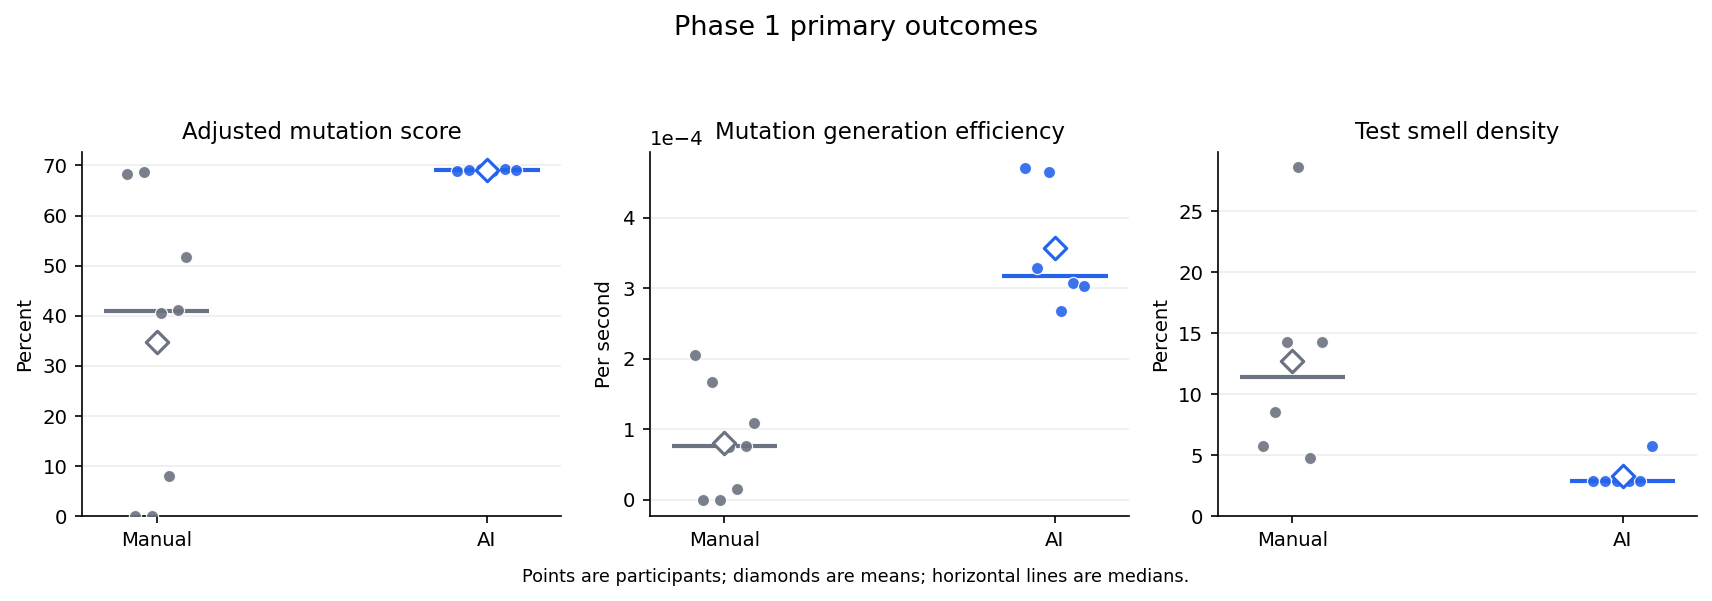

In [5]:
# Each dot is one participant. Diamonds mark means and horizontal lines mark
# medians, so the small sample, ties, and missing observations remain visible.
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6))
for ax, (metric, metadata) in zip(axes, PRIMARY_METRICS.items()):
    participant_dot_panel(ax, participants, metric, metadata)
fig.suptitle("Phase 1 primary outcomes", fontsize=13, y=1.03)
fig.text(
    0.5, -0.02,
    "Points are participants; diamonds are means; horizontal lines are medians.",
    ha="center", fontsize=8.5,
)
fig.tight_layout()
save_figure(fig, "primary_outcomes")
plt.show()
plt.close(fig)

### Figure 2. Primary mean differences and uncertainty

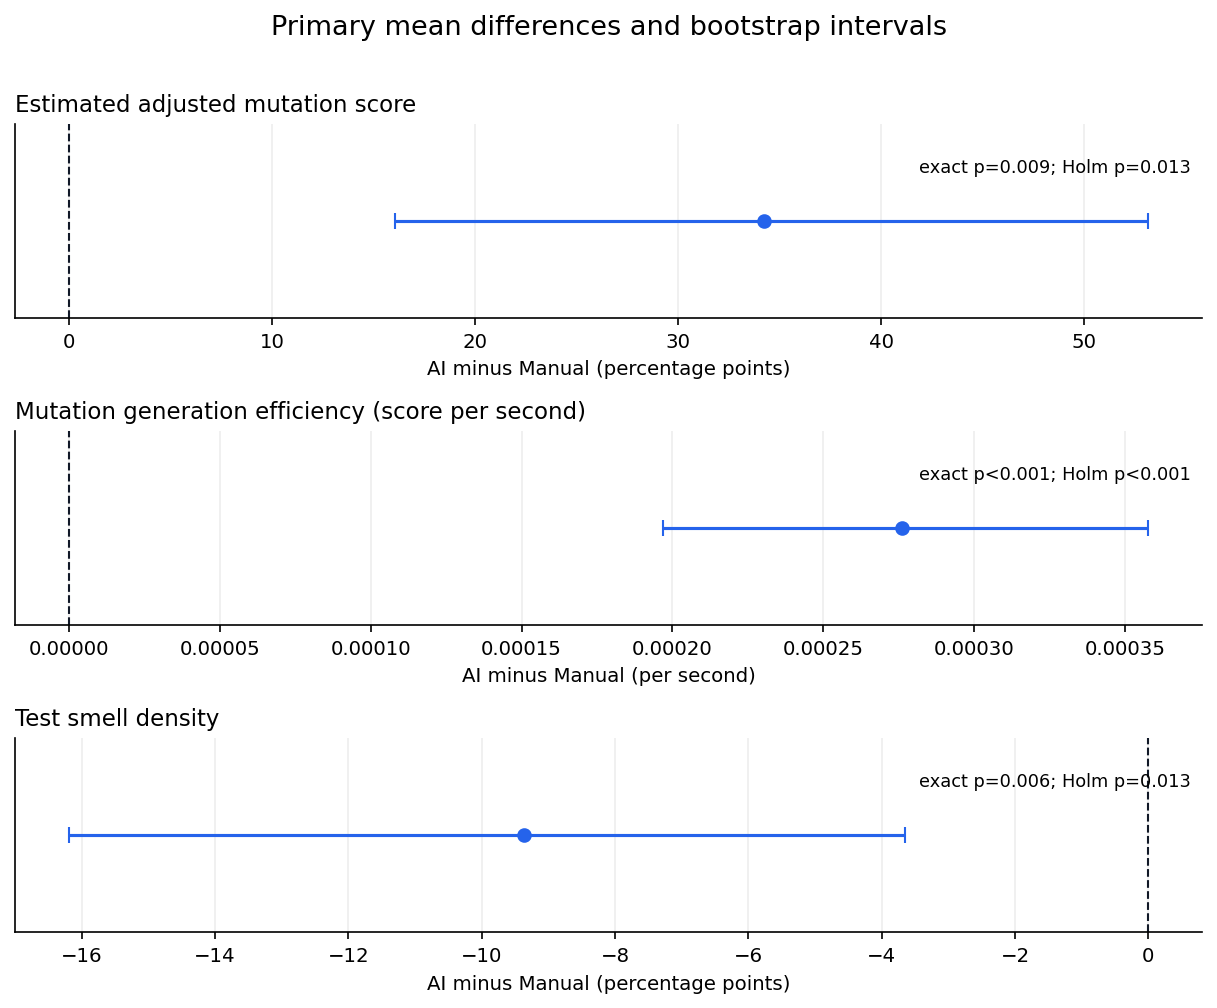

In [6]:
# Plot AI-minus-Manual mean differences. Proportions are converted to percentage
# points only for display; calculations remain on the original 0-1 scale.
fig, axes = plt.subplots(len(primary), 1, figsize=(8.2, 6.6))

def format_p(value: float) -> str:
    return "<0.001" if value < 0.001 else f"={value:.3f}"

for ax, (_, row) in zip(axes, primary.iterrows()):
    scale = str(row["scale"])
    multiplier = 100.0 if scale == "proportion" else 1.0
    estimate = row["mean_difference_ai_minus_manual"] * multiplier
    lower = row["bootstrap_ci95_lower"] * multiplier
    upper = row["bootstrap_ci95_upper"] * multiplier
    ax.axvline(0, color="#111827", linewidth=1, linestyle="--")
    ax.errorbar(
        estimate, 0, xerr=[[estimate - lower], [upper - estimate]],
        fmt="o", color="#2563EB", ecolor="#2563EB", capsize=4, markersize=6,
    )
    ax.set_yticks([])
    ax.set_title(str(row["label"]), loc="left")
    unit = "percentage points" if scale == "proportion" else "per second"
    ax.set_xlabel(f"AI minus Manual ({unit})")
    ax.text(
        0.99, 0.82,
        f"exact p{format_p(row['exact_permutation_p_value'])}; "
        f"Holm p{format_p(row['holm_adjusted_p_value'])}",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5,
    )
    ax.grid(axis="x", alpha=0.22)
    ax.grid(axis="y", visible=False)
fig.suptitle("Primary mean differences and bootstrap intervals", fontsize=13, y=1.01)
fig.tight_layout()
save_figure(fig, "primary_difference_intervals")
plt.show()
plt.close(fig)

## 4. Secondary and exploratory endpoints

These endpoints are outside the primary multiplicity family. Their p-values are
unadjusted and exploratory. Efficiency ratios should be read with their component
score and time.

In [7]:
secondary[[
    "label", "n_ai", "n_manual", "mean_ai", "mean_manual",
    "mean_difference_ai_minus_manual", "bootstrap_ci95_lower",
    "bootstrap_ci95_upper", "cliffs_delta", "exact_permutation_p_value",
]]

,label,n_ai,n_manual,mean_ai,mean_manual,mean_difference_ai_minus_manual,bootstrap_ci95_lower,bootstrap_ci95_upper,cliffs_delta,exact_permutation_p_value
0,Syntax error rate,6,8,0.000000,0.100000,-0.100000,-0.300000,0.000000,-0.125000,1.000000
1,Runtime error rate,6,8,0.000000,0.225000,-0.225000,-0.475000,-0.050000,-0.500000,0.164835
2,Function error rate,6,8,0.000000,0.093750,-0.093750,-0.218750,0.000000,-0.250000,0.472527
3,Statement coverage,6,6,0.719795,0.605486,0.114309,0.025504,0.242553,0.888889,0.010823
4,Branch coverage,6,6,0.625440,0.463047,0.162394,0.039719,0.328181,0.888889,0.010823
5,Assertion score,6,6,1.000000,0.461111,0.538889,0.261111,0.816667,0.833333,0.015152
6,Generation time (seconds),6,8,2026.166667,4641.250000,-2615.083333,-3241.544792,-1959.998958,-1.000000,0.000666
7,Execution time (seconds),6,6,0.315185,0.233656,0.081529,-0.066183,0.285293,0.444444,0.590909
8,Statement generation efficiency (coverage per ...,6,6,0.000372,0.000136,0.000236,0.000161,0.000314,1.000000,0.002165
9,Branch generation efficiency (coverage per sec...,6,6,0.000323,0.000106,0.000217,0.000146,0.000292,1.000000,0.002165


### Figure 3. Supporting effectiveness outcomes

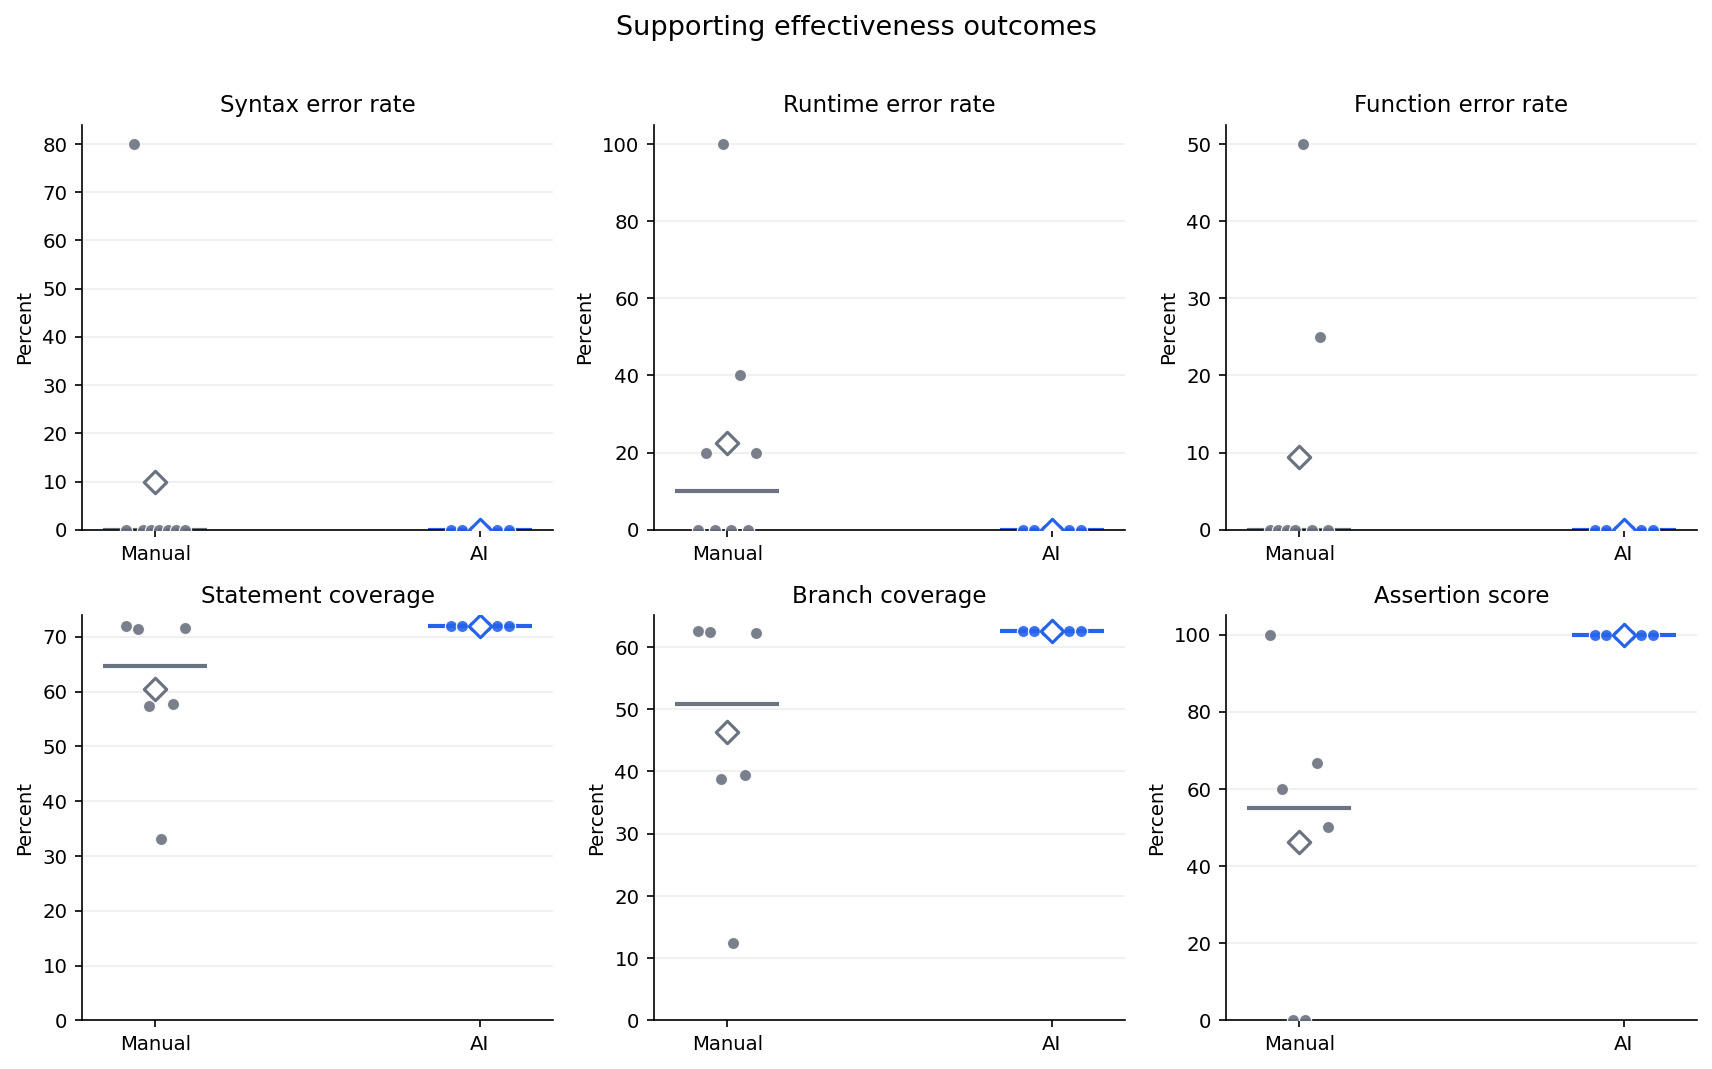

In [8]:
# The same participant-level encoding as Figure 1 supports direct comparison.
selected_metrics = [
    "syntax_error_rate", "runtime_error_rate", "function_error_rate",
    "participant_statement_coverage", "participant_branch_coverage", "assertion_score",
]
metric_metadata = all_metric_metadata()
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.0))
for ax, metric in zip(axes.flat, selected_metrics):
    participant_dot_panel(ax, participants, metric, metric_metadata[metric])
fig.suptitle("Supporting effectiveness outcomes", fontsize=13, y=1.01)
fig.tight_layout()
save_figure(fig, "secondary_effectiveness")
plt.show()
plt.close(fig)

### Figure 4. Generation time and mutation effectiveness

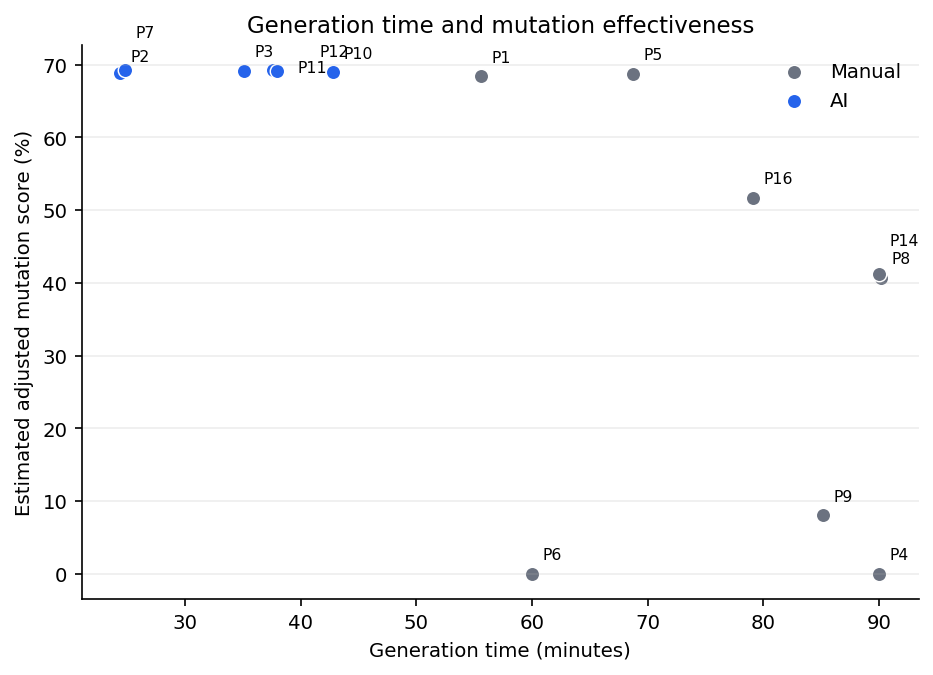

In [9]:
# Participant labels allow possible time-effectiveness trade-offs to be traced to
# the master table without aggregating away individual variation.
label_offsets = {
    1: (5, 7), 2: (5, 6), 3: (5, 7), 4: (5, 7), 5: (5, 7), 6: (5, 7),
    7: (5, 16), 8: (5, 7), 9: (5, 7), 10: (5, 7), 11: (12, -1),
    12: (20, 7), 14: (5, 14), 16: (5, 7),
}
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for group in GROUP_ORDER:
    subset = participants.loc[participants["group"].eq(group)]
    ax.scatter(
        subset["generation_time_seconds"] / 60,
        subset["specified_estimated_adjusted_mutation_score"] * 100,
        s=48, color=GROUP_COLORS[group], edgecolor="white", linewidth=0.7, label=group,
    )
    for _, row in subset.iterrows():
        participant = int(row["participant_number"])
        ax.annotate(
            f"P{participant}",
            (row["generation_time_seconds"] / 60,
             row["specified_estimated_adjusted_mutation_score"] * 100),
            xytext=label_offsets[participant], textcoords="offset points", fontsize=7.5,
        )
ax.set_xlabel("Generation time (minutes)")
ax.set_ylabel("Estimated adjusted mutation score (%)")
ax.set_title("Generation time and mutation effectiveness")
ax.legend(loc="best")
save_figure(fig, "generation_time_vs_mutation")
plt.show()
plt.close(fig)

### Figure 5. Execution time and expanded test count

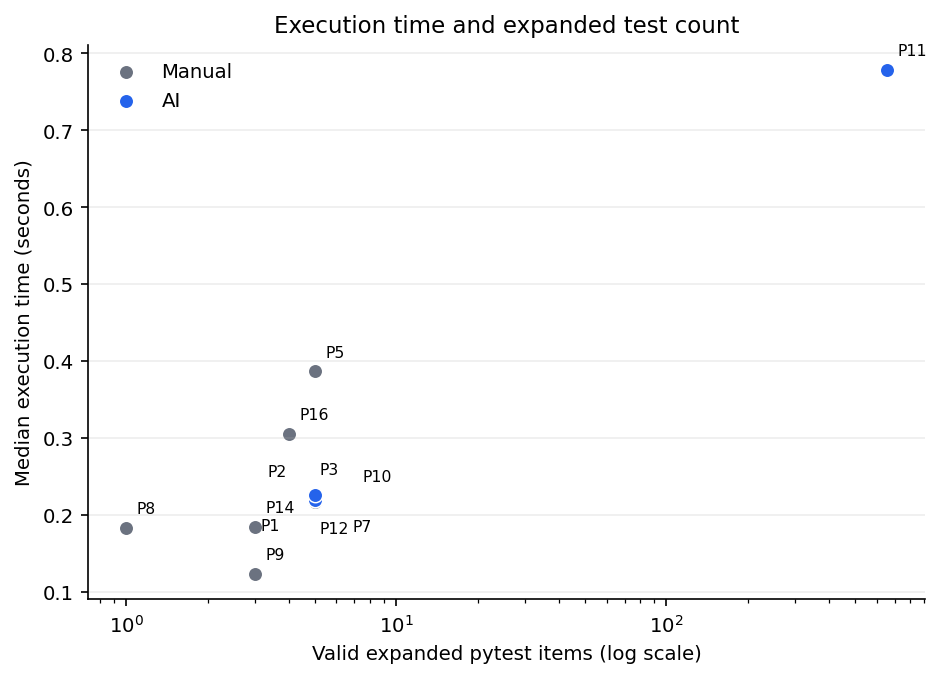

In [10]:
# A log x-axis keeps participant 11's 656 expanded pytest items visible without
# compressing the remaining participants into an unreadable cluster.
execution_data = participants.loc[participants["execution_time_seconds"].notna()].copy()
label_offsets = {
    1: (-26, -14), 2: (-23, 10), 3: (2, 11), 5: (5, 7), 7: (18, -15),
    8: (5, 7), 9: (5, 7), 10: (23, 9), 11: (5, 7), 12: (2, -18),
    14: (5, 7), 16: (5, 7),
}
fig, ax = plt.subplots(figsize=(7.2, 4.8))
for group in GROUP_ORDER:
    subset = execution_data.loc[execution_data["group"].eq(group)]
    ax.scatter(
        subset["valid_test_count"], subset["execution_time_seconds"],
        s=48, color=GROUP_COLORS[group], edgecolor="white", linewidth=0.7, label=group,
    )
    for _, row in subset.iterrows():
        participant = int(row["participant_number"])
        ax.annotate(
            f"P{participant}", (row["valid_test_count"], row["execution_time_seconds"]),
            xytext=label_offsets[participant], textcoords="offset points", fontsize=7.5,
        )
ax.set_xscale("log")
ax.set_xlabel("Valid expanded pytest items (log scale)")
ax.set_ylabel("Median execution time (seconds)")
ax.set_title("Execution time and expanded test count")
ax.legend(loc="best")
save_figure(fig, "execution_time_vs_test_count")
plt.show()
plt.close(fig)

## 5. Sensitivity analyses

These alternatives remain separate from the primary analysis: raw versus adjusted
mutation score; maximum smell-density stress testing for the two no-valid-test
submissions; lower/upper handling of participant 8's unresolved assertion; removal
of participant 11 from timing outcomes; and log-transformed time.

In [11]:
sensitivity[[
    "scenario", "n_ai", "n_manual", "mean_difference_ai_minus_manual",
    "bootstrap_ci95_lower", "bootstrap_ci95_upper", "cliffs_delta",
    "exact_permutation_p_value",
]]

,scenario,n_ai,n_manual,mean_difference_ai_minus_manual,bootstrap_ci95_lower,bootstrap_ci95_upper,cliffs_delta,exact_permutation_p_value
0,Primary adjusted mutation score,6,8,0.342471,0.159515,0.528386,1.000000,0.008658
1,Raw mutation score,6,8,0.326304,0.151813,0.506028,1.000000,0.008658
2,No-valid-test suites assigned smell density 1,6,8,-0.311905,-0.621429,-0.073810,-0.937500,0.068598
3,Assertion score: unresolved item as non-trivia...,6,6,0.538889,0.250000,0.816667,0.833333,0.015152
4,Assertion score: participant 8 unresolved item...,6,6,0.372222,0.122222,0.650000,0.666667,0.060606
5,Execution time excluding participant 11,5,6,-0.011120,-0.084332,0.053218,0.333333,0.809524
6,Mutation execution efficiency excluding partic...,5,6,1.151762,0.569798,1.753191,0.733333,0.012987
7,Log-transformed generation time,6,8,-0.835442,-1.050904,-0.623422,-1.000000,0.000333
8,Log-transformed execution time,6,6,0.228615,-0.199679,0.737773,0.444444,0.452381


### Figure 6. Confirmed test-smell pairs by type

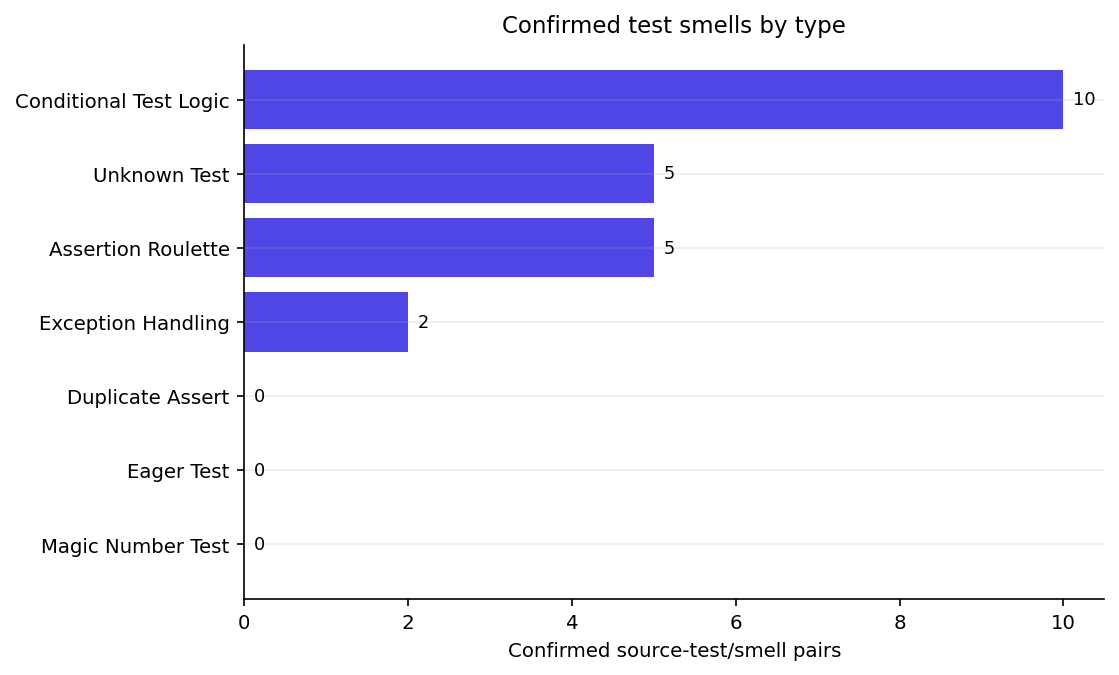

In [12]:
# Counts follow the seven frozen Phase 1 smell definitions. Sorting supports a
# clear ranking; the chart does not replace the density-based primary endpoint.
smell_columns = {
    "assertion_roulette_count": "Assertion Roulette",
    "magic_number_test_count": "Magic Number Test",
    "unknown_test_count": "Unknown Test",
    "conditional_test_logic_count": "Conditional Test Logic",
    "eager_test_count": "Eager Test",
    "duplicate_assert_count": "Duplicate Assert",
    "exception_handling_count": "Exception Handling",
}
smell_totals = participants[list(smell_columns)].sum().rename(index=smell_columns).sort_values()
fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.barh(smell_totals.index, smell_totals.values, color="#4F46E5")
ax.set_xlabel("Confirmed source-test/smell pairs")
ax.set_title("Confirmed test smells by type")
ax.set_xlim(left=0)
for y, value in enumerate(smell_totals.values):
    ax.text(value + 0.12, y, f"{int(value)}", va="center", fontsize=8.5)
save_figure(fig, "test_smell_types")
plt.show()
plt.close(fig)

## 6. Questionnaire outputs

The AI and Manual post-surveys use different questions, so item scores are not
directly compared. Each version is summarized separately. Open-ended answers are
exported to a coding table for manual thematic analysis.

In [13]:
likert[["survey", "item_order", "item", "n", "median", "first_quartile", "third_quartile"]]

,survey,item_order,item,n,median,first_quartile,third_quartile
0,AI post-survey,1,Using GitHub Copilot allowed me to complete th...,6,5.0,5.00,5.00
1,AI post-survey,2,Using GitHub Copilot helped me achieve better ...,6,3.5,3.00,4.00
2,AI post-survey,3,"Overall, I found GitHub Copilot to be a useful...",6,5.0,5.00,5.00
3,AI post-survey,4,"In practice, Copilot accurately captured the i...",6,4.0,4.00,4.75
4,AI post-survey,5,The test cases generated by Copilot were mostl...,6,4.5,4.00,5.00
5,AI post-survey,6,"Copilot frequently generated ""hallucinated"" as...",6,2.0,1.25,2.00
6,AI post-survey,7,I was able to write effective comments or prom...,6,4.0,4.00,4.75
7,AI post-survey,8,I was able to accurately identify flaws or inv...,6,4.0,3.25,4.00
8,AI post-survey,9,I was able to effectively adapt my testing wor...,6,4.5,4.00,5.00
9,Manual post-survey,1,(1) I was able to create tests that meaningful...,8,3.0,3.00,4.00


### Figure 7. AI post-survey Likert distributions

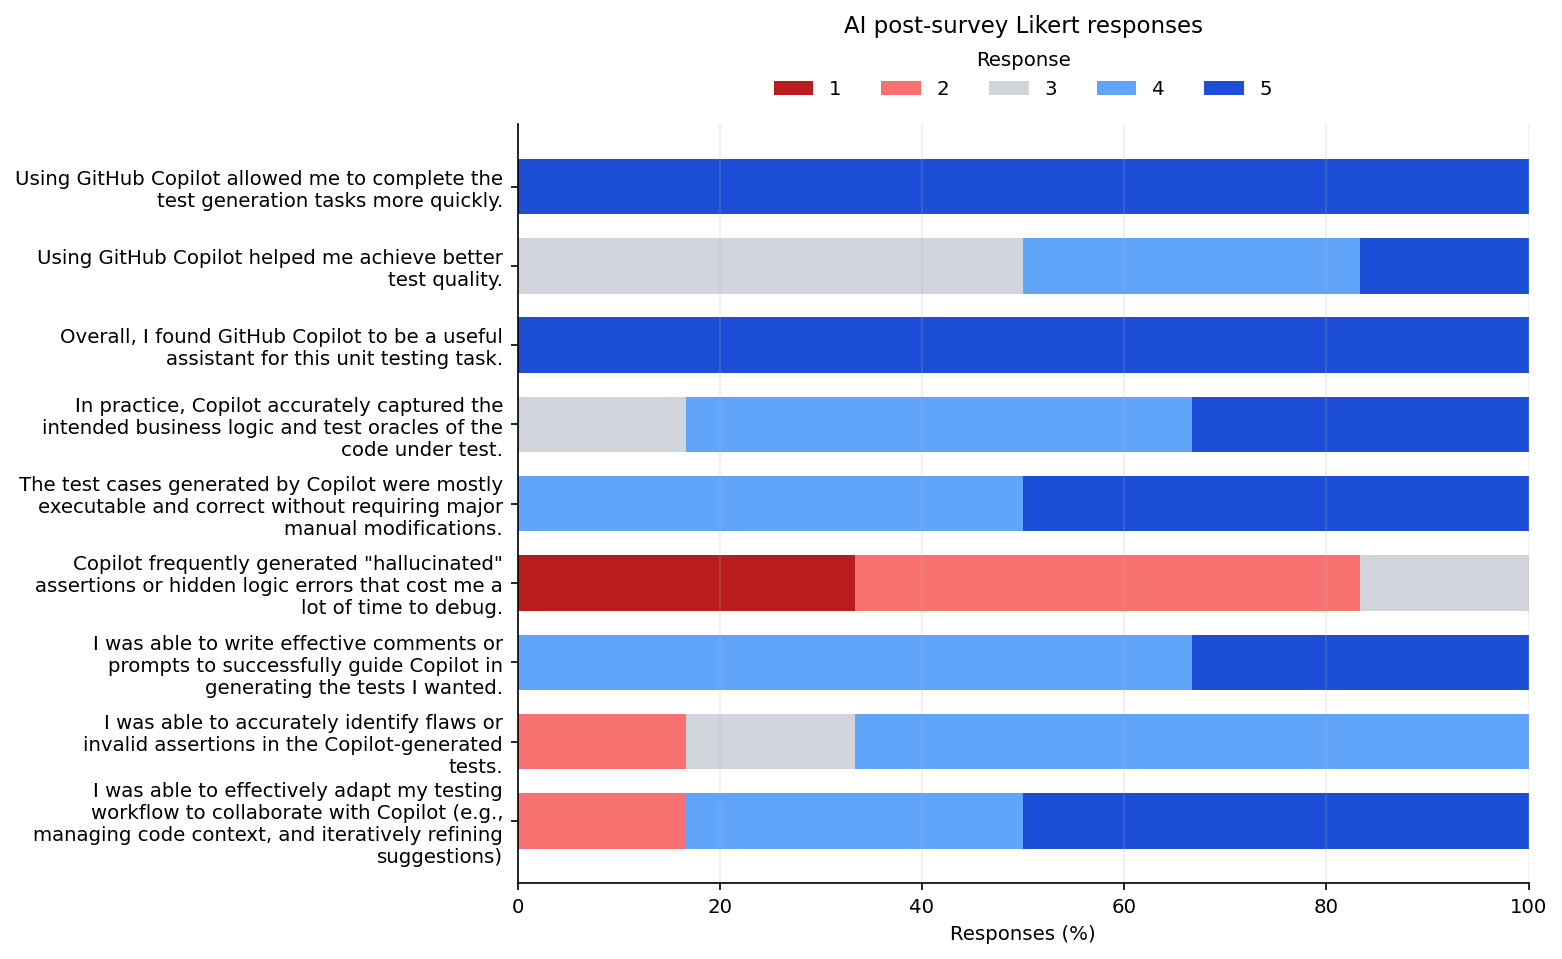

In [14]:
# Items are kept separate rather than combined into an unvalidated composite.
survey_name = "AI post-survey"
survey_data = likert.loc[likert["survey"].eq(survey_name)].sort_values("item_order")
labels = [fill(str(item), width=48) for item in survey_data["item"]]
colors = ["#B91C1C", "#F87171", "#D1D5DB", "#60A5FA", "#1D4ED8"]
fig, ax = plt.subplots(figsize=(10.5, max(5.5, len(survey_data) * 0.72)))
left = np.zeros(len(survey_data))
for score, color in zip(range(1, 6), colors):
    values = survey_data[f"score_{score}_percent"].to_numpy(dtype=float)
    ax.barh(labels, values, left=left, color=color, label=str(score), height=0.7)
    left += values
ax.set_xlim(0, 100)
ax.set_xlabel("Responses (%)")
ax.set_title(f"{survey_name} Likert responses", pad=44)
ax.legend(title="Response", ncol=5, loc="lower center", bbox_to_anchor=(0.5, 1.01))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.22)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "likert_ai_post")
plt.show()
plt.close(fig)

### Figure 8. Manual post-survey Likert distributions

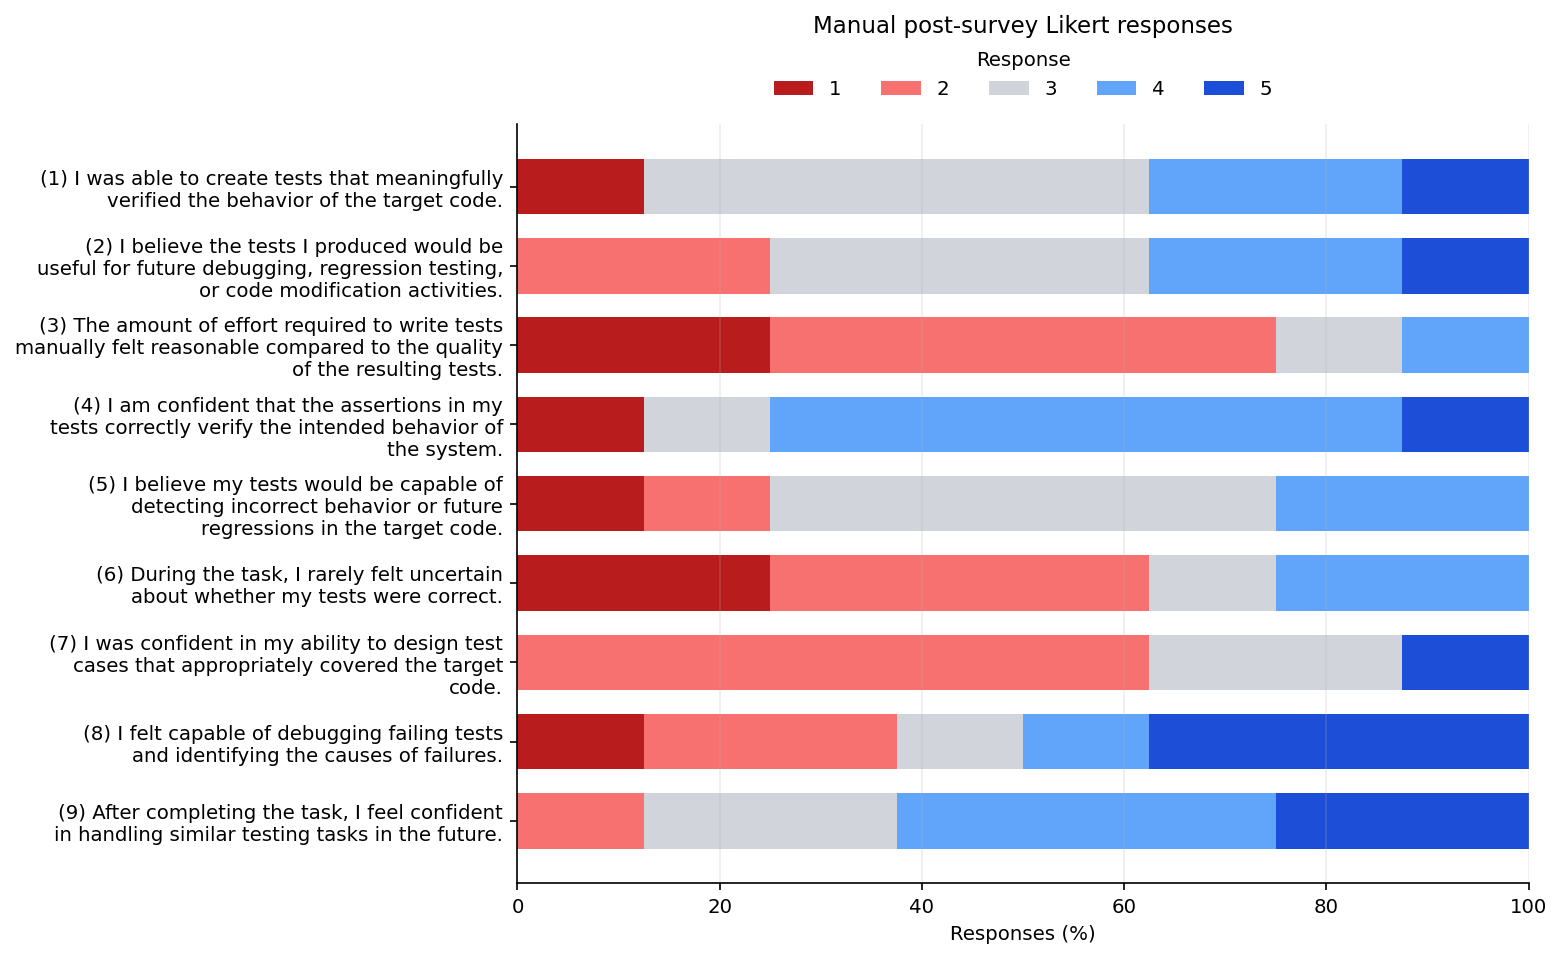

In [15]:
# This survey is plotted independently because its questions differ from the AI
# version; matching colors encode response categories, not comparable constructs.
survey_name = "Manual post-survey"
survey_data = likert.loc[likert["survey"].eq(survey_name)].sort_values("item_order")
labels = [fill(str(item), width=48) for item in survey_data["item"]]
colors = ["#B91C1C", "#F87171", "#D1D5DB", "#60A5FA", "#1D4ED8"]
fig, ax = plt.subplots(figsize=(10.5, max(5.5, len(survey_data) * 0.72)))
left = np.zeros(len(survey_data))
for score, color in zip(range(1, 6), colors):
    values = survey_data[f"score_{score}_percent"].to_numpy(dtype=float)
    ax.barh(labels, values, left=left, color=color, label=str(score), height=0.7)
    left += values
ax.set_xlim(0, 100)
ax.set_xlabel("Responses (%)")
ax.set_title(f"{survey_name} Likert responses", pad=44)
ax.legend(title="Response", ncol=5, loc="lower center", bbox_to_anchor=(0.5, 1.01))
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.22)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_figure(fig, "likert_manual_post")
plt.show()
plt.close(fig)

## 7. Interpretation boundary

These results estimate Phase 1 group differences under the observed allocation.
Because the stratified-randomization record is unavailable, the analysis does not
adjust for randomization strata and avoids stronger causal claims. Phase 2 is
required before evaluating longitudinal maintenance or the crossover design.